# Data Collection for Volatility Spillover Analysis

**Purpose:** Download and prepare asset price data for cross-asset volatility spillover analysis

**Assets:**
- **Equities:** S&P 500 (^GSPC)
- **Fixed Income:** iShares 7-10 Year Treasury ETF (IEF)
- **Commodities:** Gold (GC=F), Crude Oil (CL=F), Natural Gas (NG=F), Wheat (ZW=F)
- **ESG/Clean Energy:** Invesco WilderHill Clean Energy ETF (PBW)

**Sample Period:** 2005-01-01 to 2025-06-30

**Output Structure:**
```
data/
├── raw/              # Individual asset downloads
├── processed/        # Merged and cleaned data
└── metadata/         # Asset classifications and metadata
```

## Setup and Configuration

In [21]:
import pandas as pd
import numpy as np
import yfinance as yf
import warnings
import time
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller, kpss
from scipy.stats import skew, kurtosis

warnings.filterwarnings('ignore')

# Create directory structure
DATA_DIR = Path('../data')
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
METADATA_DIR = DATA_DIR / 'metadata'

for directory in [RAW_DIR, PROCESSED_DIR, METADATA_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("✓ Directory structure created")
print(f"  - Raw data: {RAW_DIR}")
print(f"  - Processed data: {PROCESSED_DIR}")
print(f"  - Metadata: {METADATA_DIR}")

✓ Directory structure created
  - Raw data: ..\data\raw
  - Processed data: ..\data\processed
  - Metadata: ..\data\metadata


## Asset Configuration

Define all assets with metadata for categorization (used in ML analysis)

In [22]:
# Asset definitions with metadata for ML basketing
ASSETS = {
    "S&P_500": {
        "ticker": "^GSPC",
        "name": "S&P 500 Index",
        "asset_class": "Equity",
        "sub_class": "Broad Market",
        "start_date": "2005-01-01"
    },
    "IEF": {
        "ticker": "IEF",
        "name": "iShares 7-10 Year Treasury Bond ETF",
        "asset_class": "Fixed Income",
        "sub_class": "Government Bonds",
        "start_date": "2005-01-01"
    },
    "Gold": {
        "ticker": "GC=F",
        "name": "Gold Futures",
        "asset_class": "Commodity",
        "sub_class": "Precious Metals",
        "start_date": "2005-01-01"
    },
    "Crude_Oil": {
        "ticker": "CL=F",
        "name": "Crude Oil Futures",
        "asset_class": "Commodity",
        "sub_class": "Energy",
        "start_date": "2005-01-01"
    },
    "Natural_Gas": {
        "ticker": "NG=F",
        "name": "Natural Gas Futures",
        "asset_class": "Commodity",
        "sub_class": "Energy",
        "start_date": "2005-01-01"
    },
    "Wheat": {
        "ticker": "ZW=F",
        "name": "Wheat Futures",
        "asset_class": "Commodity",
        "sub_class": "Agriculture",
        "start_date": "2005-01-01"
    },
    "PBW": {
        "ticker": "PBW",
        "name": "Invesco WilderHill Clean Energy ETF",
        "asset_class": "Equity",
        "sub_class": "ESG/Clean Energy",
        "start_date": "2005-03-03"  # PBW inception date
    }
}

END_DATE = "2025-06-30"

# Save metadata
metadata_df = pd.DataFrame(ASSETS).T
metadata_df.to_csv(METADATA_DIR / 'asset_metadata.csv')
print("✓ Asset metadata saved")
print("\nAsset Classes:")
print(metadata_df[['asset_class', 'sub_class']])

✓ Asset metadata saved

Asset Classes:
              asset_class         sub_class
S&P_500            Equity      Broad Market
IEF          Fixed Income  Government Bonds
Gold            Commodity   Precious Metals
Crude_Oil       Commodity            Energy
Natural_Gas     Commodity            Energy
Wheat           Commodity       Agriculture
PBW                Equity  ESG/Clean Energy


## Download Asset Data

Download with retry logic to handle rate limiting

In [23]:
def download_asset(asset_name, config, max_retries=3, delay=2):
    """
    Download asset data with retry logic for rate limiting.
    
    Parameters:
    -----------
    asset_name : str
        Name of the asset (used for column naming)
    config : dict
        Asset configuration with ticker and date info
    max_retries : int
        Maximum number of retry attempts
    delay : float
        Delay between retries in seconds
    """
    ticker = config['ticker']
    start = config['start_date']
    
    for attempt in range(max_retries):
        try:
            print(f"  Downloading {asset_name} ({ticker})...", end=" ")
            data = yf.download(ticker, start=start, end=END_DATE, progress=False)
            
            if data.empty:
                raise ValueError(f"No data returned for {ticker}")
            
            # Extract Close column and ensure it's numeric
            if isinstance(data.columns, pd.MultiIndex):
                # Handle MultiIndex columns (happens with single ticker sometimes)
                close_data = data['Close'].iloc[:, 0] if len(data['Close'].shape) > 1 else data['Close']
            else:
                close_data = data['Close']
            
            # Convert to DataFrame and ensure numeric type
            df = pd.DataFrame({asset_name: pd.to_numeric(close_data, errors='coerce')})
            df = df.dropna()  # Remove any NaN values from conversion
            
            # Save individual asset file
            output_path = RAW_DIR / f"{asset_name}.csv"
            df.to_csv(output_path)
            
            print(f"✓ ({len(df)} rows)")
            time.sleep(delay)  # Respectful delay between requests
            return df
            
        except Exception as e:
            print(f"✗ (Attempt {attempt + 1}/{max_retries})")
            if attempt < max_retries - 1:
                wait_time = delay * (2 ** attempt)  # Exponential backoff
                print(f"    Waiting {wait_time}s before retry...")
                time.sleep(wait_time)
            else:
                print(f"    Failed after {max_retries} attempts: {e}")
                return None

# Download all assets
print("\nDownloading asset data...\n")
downloaded_data = {}

for asset_name, config in ASSETS.items():
    data = download_asset(asset_name, config)
    if data is not None:
        downloaded_data[asset_name] = data

print(f"\n✓ Successfully downloaded {len(downloaded_data)}/{len(ASSETS)} assets")




✓ Successfully downloaded 7/7 assets


## Merge and Align Data

Combine all assets with common date index

In [24]:
# Load all downloaded files and ensure numeric types
price_dfs = []

for asset_name in downloaded_data.keys():
    df = pd.read_csv(RAW_DIR / f"{asset_name}.csv", parse_dates=['Date'], index_col='Date')
    # Ensure the column is numeric
    df[asset_name] = pd.to_numeric(df[asset_name], errors='coerce')
    price_dfs.append(df)

# Merge all assets (inner join to align dates)
all_prices = pd.concat(price_dfs, axis=1, join='inner')

# Drop any rows with NaN values (from failed conversions)
all_prices = all_prices.dropna()

# Verify all columns are numeric
print(f"\nData Types:")
print(all_prices.dtypes)

print(f"\nMerged Data Summary:")
print(f"  Date range: {all_prices.index.min()} to {all_prices.index.max()}")
print(f"  Total observations: {len(all_prices)}")
print(f"  Assets: {', '.join(all_prices.columns)}")

# Check for missing values
missing = all_prices.isnull().sum()
if missing.sum() > 0:
    print(f"\n⚠ Missing values detected:")
    print(missing[missing > 0])
else:
    print("\n✓ No missing values")

# Verify numeric data
print(f"\nFirst few rows:")
print(all_prices.head())

# Save merged prices
output_path = PROCESSED_DIR / 'all_assets_prices.csv'
all_prices.to_csv(output_path)
print(f"\n✓ Merged prices saved to {output_path.relative_to(DATA_DIR.parent)}")


Data Types:
S&P_500        float64
IEF            float64
Gold           float64
Crude_Oil      float64
Natural_Gas    float64
Wheat          float64
PBW            float64
dtype: object

Merged Data Summary:
  Date range: 2005-03-03 00:00:00 to 2025-06-27 00:00:00
  Total observations: 5103
  Assets: S&P_500, IEF, Gold, Crude_Oil, Natural_Gas, Wheat, PBW

✓ No missing values

First few rows:
                S&P_500        IEF        Gold  Crude_Oil  Natural_Gas  \
Date                                                                     
2005-03-03  1210.469971  48.173378  429.899994  53.570000        6.657   
2005-03-04  1222.119995  48.391354  434.200012  53.779999        6.744   
2005-03-07  1225.310059  48.402878  435.000000  53.889999        6.714   
2005-03-08  1219.430054  48.173378  440.299988  54.590000        6.847   
2005-03-09  1207.010010  47.806206  442.100006  54.770000        6.880   

             Wheat        PBW  
Date                           
2005-03-03  330.00  

## Compute Log Returns

In [25]:
# Calculate log returns
log_returns = np.log(all_prices / all_prices.shift(1)).dropna()

# Check for any infinite or extreme values
inf_check = np.isinf(log_returns).sum().sum()
if inf_check > 0:
    print(f"⚠ Warning: {inf_check} infinite values detected. Removing...")
    log_returns = log_returns.replace([np.inf, -np.inf], np.nan).dropna()

print(f"\nLog Returns Summary:")
print(f"  Observations: {len(log_returns)}")
print(f"  Date range: {log_returns.index.min()} to {log_returns.index.max()}")

# Save log returns
output_path = PROCESSED_DIR / 'all_assets_log_returns.csv'
log_returns.to_csv(output_path)
print(f"\n✓ Log returns saved to {output_path.relative_to(DATA_DIR.parent)}")


Log Returns Summary:
  Observations: 5100
  Date range: 2005-03-04 00:00:00 to 2025-06-27 00:00:00

✓ Log returns saved to data\processed\all_assets_log_returns.csv


## Descriptive Statistics

In [26]:
# Calculate comprehensive statistics
desc = log_returns.describe().T

# Add skewness and kurtosis
desc['skew'] = log_returns.apply(skew)
desc['kurtosis_excess'] = log_returns.apply(lambda x: kurtosis(x, fisher=True))

# Annualize metrics (252 trading days)
desc['ann_mean'] = desc['mean'] * 252
desc['ann_vol'] = desc['std'] * np.sqrt(252)
desc['sharpe'] = desc['ann_mean'] / desc['ann_vol']

# Add asset class info
desc['asset_class'] = [ASSETS[asset]['asset_class'] for asset in desc.index]
desc['sub_class'] = [ASSETS[asset]['sub_class'] for asset in desc.index]

# Reorder columns for clarity
cols = ['asset_class', 'sub_class', 'count', 'mean', 'std', 'ann_mean', 'ann_vol', 
        'sharpe', 'skew', 'kurtosis_excess', 'min', 'max']
desc = desc[cols]

# Save statistics
output_path = PROCESSED_DIR / 'descriptive_statistics.csv'
desc.to_csv(output_path)

print("\nDescriptive Statistics by Asset Class:\n")
print(desc.round(4))
print(f"\n✓ Statistics saved to {output_path.relative_to(DATA_DIR.parent)}")


Descriptive Statistics by Asset Class:

              asset_class         sub_class   count    mean     std  ann_mean  \
S&P_500            Equity      Broad Market  5100.0  0.0003  0.0122    0.0829   
IEF          Fixed Income  Government Bonds  5100.0  0.0001  0.0043    0.0322   
Gold            Commodity   Precious Metals  5100.0  0.0004  0.0112    0.1006   
Crude_Oil       Commodity            Energy  5100.0  0.0002  0.0262    0.0397   
Natural_Gas     Commodity            Energy  5100.0 -0.0001  0.0363   -0.0304   
Wheat           Commodity       Agriculture  5100.0  0.0001  0.0210    0.0217   
PBW                Equity  ESG/Clean Energy  5100.0 -0.0002  0.0231   -0.0493   

             ann_vol  sharpe    skew  kurtosis_excess     min     max  
S&P_500       0.1941  0.4273 -0.4713          13.0145 -0.1277  0.1096  
IEF           0.0686  0.4698  0.1071           2.6211 -0.0254  0.0337  
Gold          0.1783  0.5644 -0.3321           5.2357 -0.0982  0.0864  
Crude_Oil     0.4163  

## Stationarity Testing

Verify that return series are stationary (required for GARCH modeling)

- **ADF Test:** H₀ = Unit Root (reject if p < 0.05 → stationary)
- **KPSS Test:** H₀ = Stationary (fail to reject if stat < critical → stationary)

In [27]:
# Run stationarity tests
stationarity_results = []

for asset in log_returns.columns:
    series = log_returns[asset].dropna()
    
    # ADF test
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series, regression='c', autolag='AIC')
    
    # KPSS test
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_stat, kpss_p, _, kpss_crit = kpss(series, regression='c', nlags='auto')
    
    stationarity_results.append({
        'Asset': asset,
        'ADF_stat': adf_stat,
        'ADF_p_value': adf_p,
        'ADF_stationary': 'Yes' if adf_p < 0.05 else 'No',
        'KPSS_stat': kpss_stat,
        'KPSS_crit_5%': kpss_crit['5%'],
        'KPSS_stationary': 'Yes' if kpss_stat < kpss_crit['5%'] else 'No',
        'Overall': 'Stationary' if (adf_p < 0.05 and kpss_stat < kpss_crit['5%']) else 'Check'
    })

stationarity_df = pd.DataFrame(stationarity_results).set_index('Asset')

# Save results
output_path = PROCESSED_DIR / 'stationarity_tests.csv'
stationarity_df.to_csv(output_path)

print("\nStationarity Test Results:\n")
print(stationarity_df[['ADF_p_value', 'ADF_stationary', 'KPSS_stat', 
                        'KPSS_crit_5%', 'KPSS_stationary', 'Overall']].round(4))
print(f"\n✓ Results saved to {output_path.relative_to(DATA_DIR.parent)}")

# Check if all series are stationary
all_stationary = (stationarity_df['Overall'] == 'Stationary').all()
if all_stationary:
    print("\n✓ All return series are STATIONARY (suitable for GARCH modeling)")
else:
    print("\n⚠ Some series may require further investigation")


Stationarity Test Results:

             ADF_p_value ADF_stationary  KPSS_stat  KPSS_crit_5%  \
Asset                                                              
S&P_500              0.0            Yes     0.1886         0.463   
IEF                  0.0            Yes     0.3670         0.463   
Gold                 0.0            Yes     0.1757         0.463   
Crude_Oil            0.0            Yes     0.0462         0.463   
Natural_Gas          0.0            Yes     0.0377         0.463   
Wheat                0.0            Yes     0.0781         0.463   
PBW                  0.0            Yes     0.1025         0.463   

            KPSS_stationary     Overall  
Asset                                    
S&P_500                 Yes  Stationary  
IEF                     Yes  Stationary  
Gold                    Yes  Stationary  
Crude_Oil               Yes  Stationary  
Natural_Gas             Yes  Stationary  
Wheat                   Yes  Stationary  
PBW                   

## Visualizations

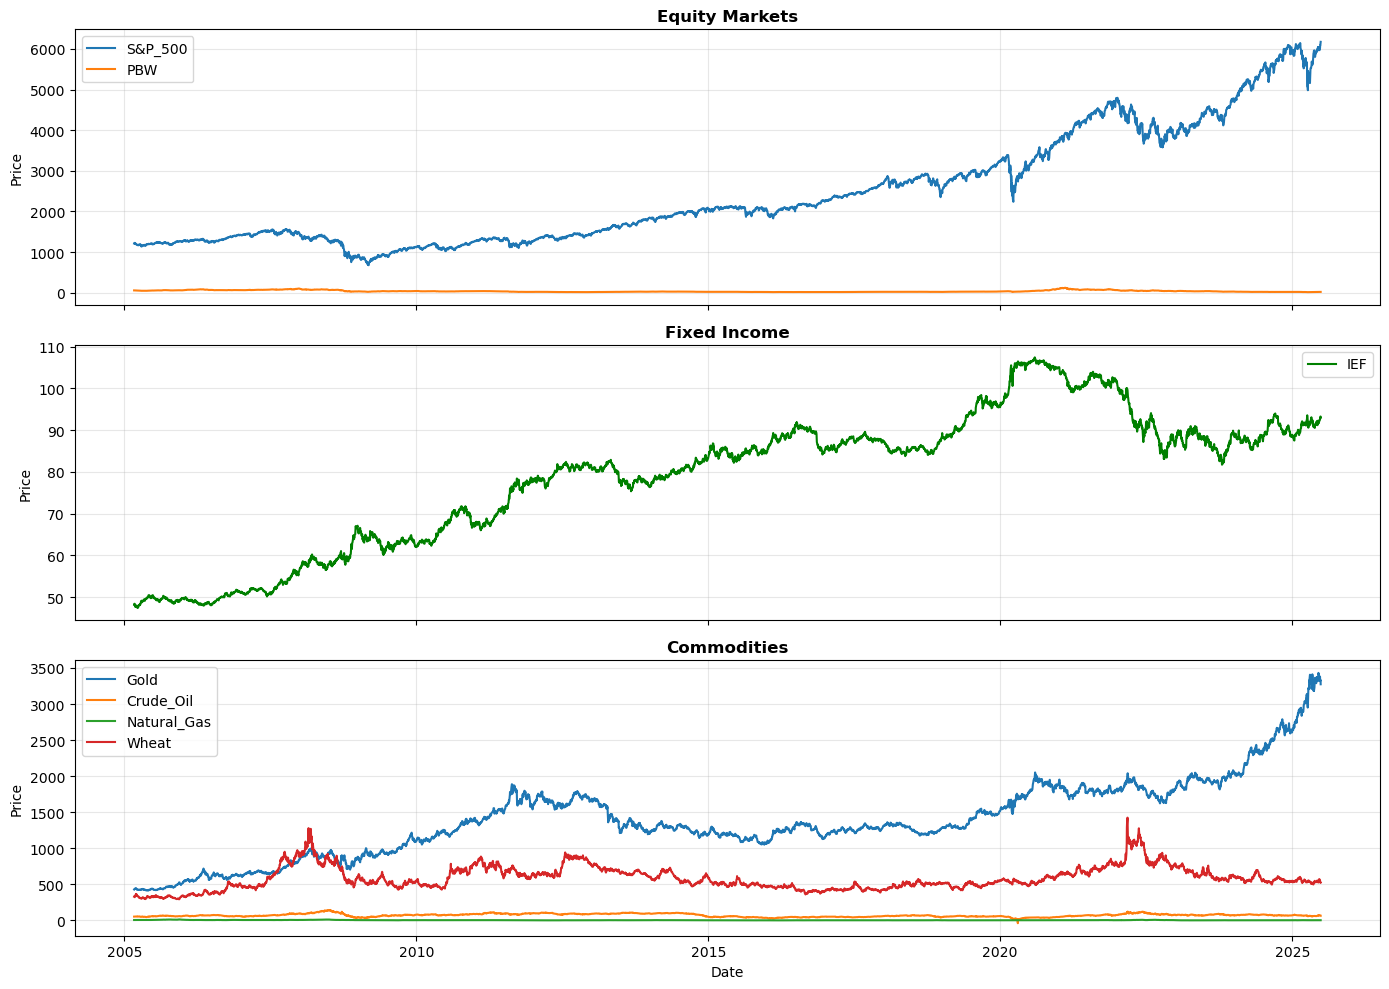

✓ Price visualization saved


In [28]:
# Plot price levels by asset class
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Equities
equity_assets = [a for a in all_prices.columns if ASSETS[a]['asset_class'] == 'Equity']
for asset in equity_assets:
    axs[0].plot(all_prices.index, all_prices[asset], label=asset, linewidth=1.5)
axs[0].set_title('Equity Markets', fontsize=12, fontweight='bold')
axs[0].set_ylabel('Price', fontsize=10)
axs[0].legend(loc='best')
axs[0].grid(True, alpha=0.3)

# Fixed Income
bond_assets = [a for a in all_prices.columns if ASSETS[a]['asset_class'] == 'Fixed Income']
for asset in bond_assets:
    axs[1].plot(all_prices.index, all_prices[asset], label=asset, color='green', linewidth=1.5)
axs[1].set_title('Fixed Income', fontsize=12, fontweight='bold')
axs[1].set_ylabel('Price', fontsize=10)
axs[1].legend(loc='best')
axs[1].grid(True, alpha=0.3)

# Commodities
commodity_assets = [a for a in all_prices.columns if ASSETS[a]['asset_class'] == 'Commodity']
for asset in commodity_assets:
    axs[2].plot(all_prices.index, all_prices[asset], label=asset, linewidth=1.5)
axs[2].set_title('Commodities', fontsize=12, fontweight='bold')
axs[2].set_ylabel('Price', fontsize=10)
axs[2].legend(loc='best')
axs[2].grid(True, alpha=0.3)

# Format x-axis
axs[2].xaxis.set_major_locator(mdates.YearLocator(5))
axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xlabel('Date', fontsize=10)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'price_levels_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Price visualization saved")

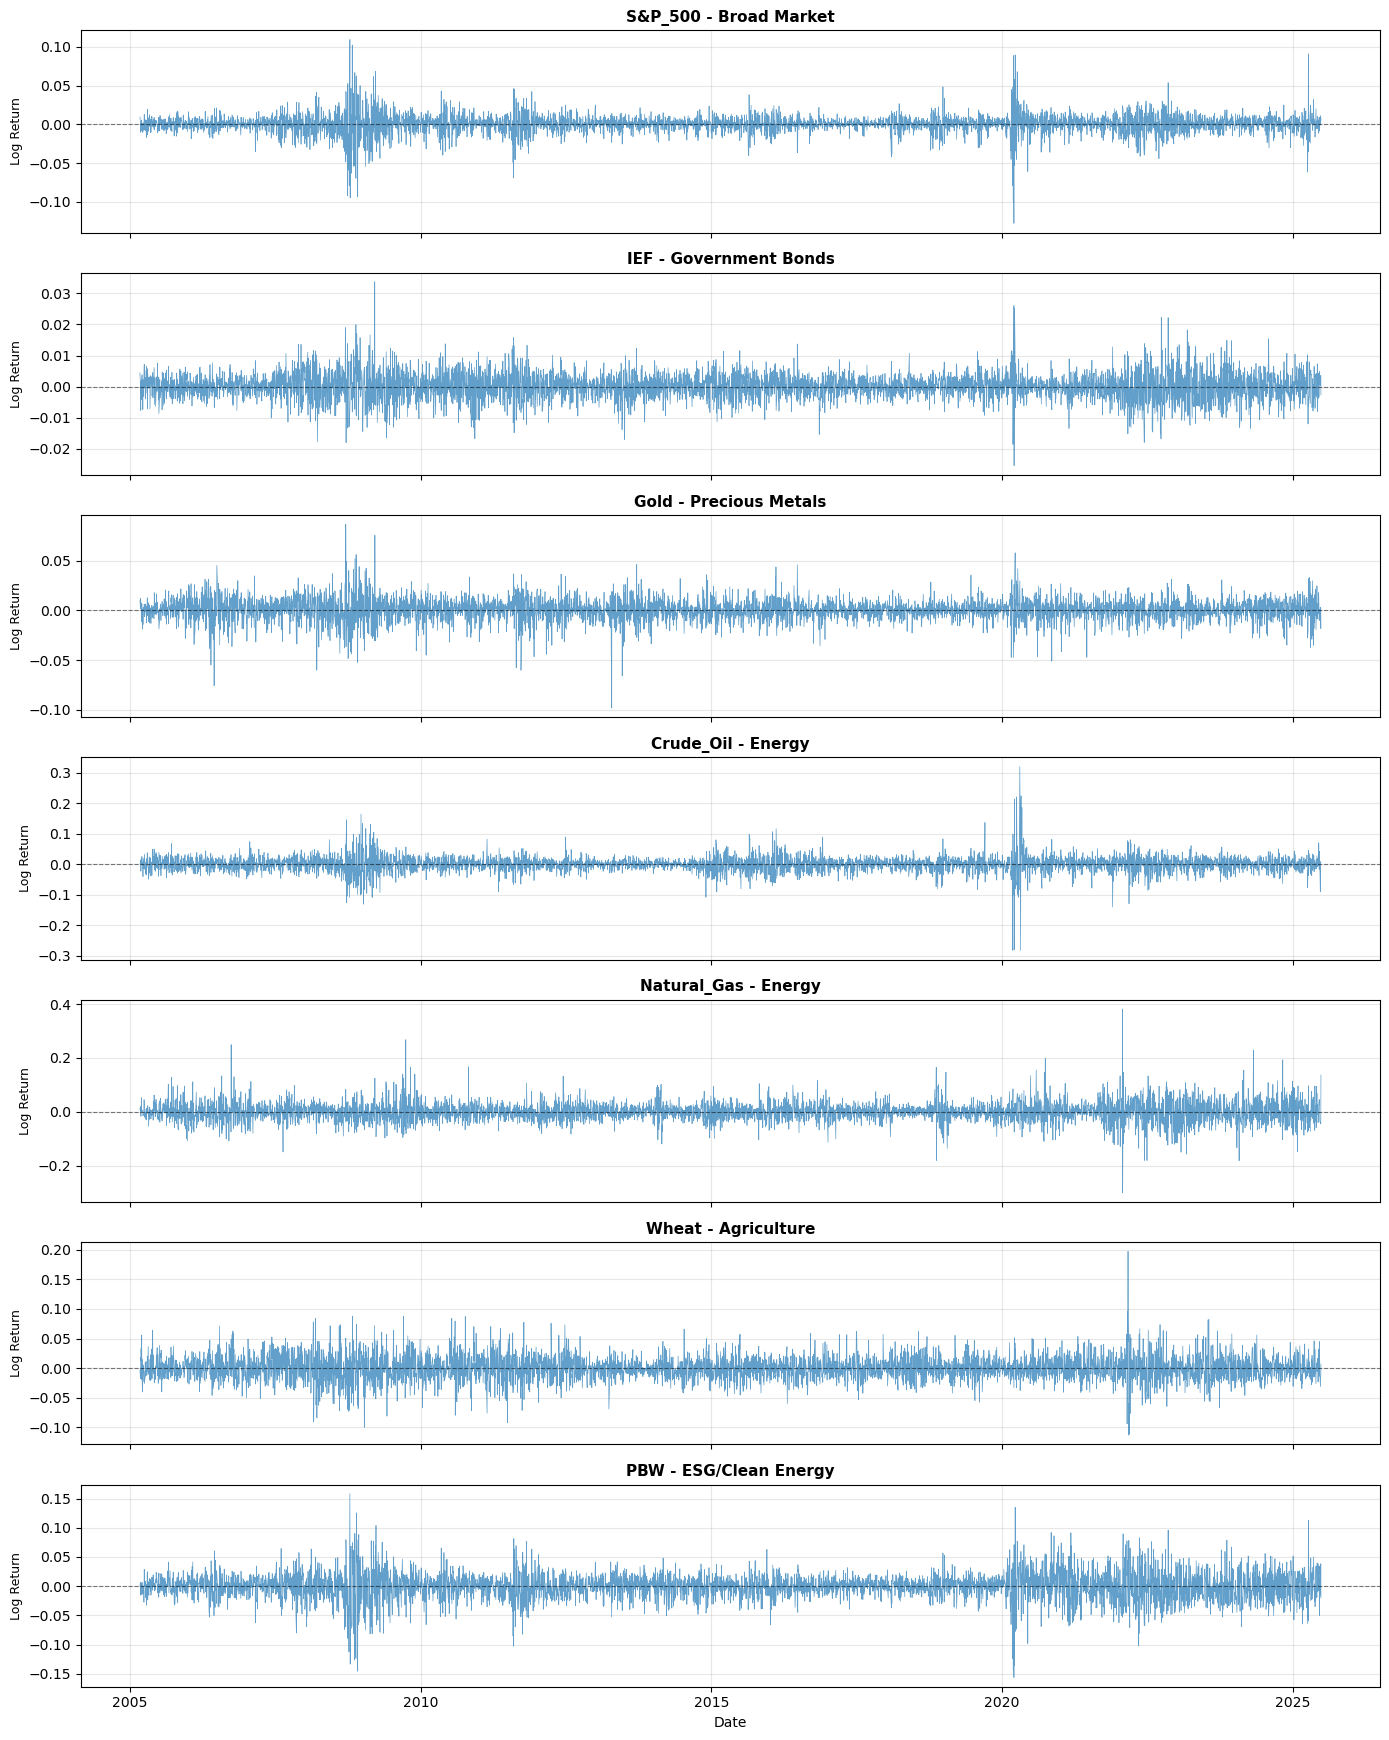

✓ Returns visualization saved


In [29]:
# Plot log returns by asset
n_assets = len(log_returns.columns)
fig, axs = plt.subplots(n_assets, 1, figsize=(14, 2.5 * n_assets), sharex=True)

if n_assets == 1:
    axs = [axs]

for i, asset in enumerate(log_returns.columns):
    asset_class = ASSETS[asset]['asset_class']
    sub_class = ASSETS[asset]['sub_class']
    
    axs[i].plot(log_returns.index, log_returns[asset], linewidth=0.5, alpha=0.7)
    axs[i].axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    axs[i].set_title(f"{asset} - {sub_class}", fontsize=11, fontweight='bold')
    axs[i].set_ylabel('Log Return', fontsize=9)
    axs[i].grid(True, alpha=0.3)

# Format x-axis
axs[-1].xaxis.set_major_locator(mdates.YearLocator(5))
axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xlabel('Date', fontsize=10)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'log_returns_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Returns visualization saved")

## Summary

### ✓ Data Collection Complete

**Outputs Created:**
1. **Raw Data** (`data/raw/`): Individual asset CSV files
2. **Processed Data** (`data/processed/`):
   - `all_assets_prices.csv` - Merged price levels
   - `all_assets_log_returns.csv` - Log returns (ready for GARCH)
   - `descriptive_statistics.csv` - Summary statistics
   - `stationarity_tests.csv` - ADF and KPSS test results
3. **Metadata** (`data/metadata/`):
   - `asset_metadata.csv` - Asset classifications for ML basketing

**Key Findings:**
- All return series are stationary (suitable for GARCH modeling)
- Assets categorized by class (Equity, Fixed Income, Commodity) and sub-class
- Date range aligned across all assets

**Next Steps:**
→ Proceed to `02_GARCH_DCC_GARCH.ipynb` for volatility modeling